# NovaPay - Fraudulent Transaction Detection for Digital Money Transfer

## Day 7: Explainability & Stakeholder Review

Day 7 focuses on model transparency. Fraud detection models need to be understandable to analysts, stakeholders, and regulators, especially when a legitimate customer's transaction is delayed or reviewed.

This notebook explains individual fraud predictions, creates regulator-friendly reason codes, reviews false positives, and saves analyst templates that can be used during manual investigation.

## 1. Import Libraries

The notebook uses the Day 6 trained model where possible. SHAP is used for transaction-level explanations, with a feature-importance fallback if SHAP is unavailable in the execution environment.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print("SHAP is unavailable. The notebook will use feature importance as a fallback.")
    print("Import error:", exc)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False
    print("XGBoost is unavailable. Fallback retraining will be skipped unless the saved model loads.")
    print("Import error:", exc)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except Exception as exc:
    SMOTE = None
    ImbPipeline = Pipeline
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is unavailable. Fallback retraining will use class weighting only.")
    print("Import error:", exc)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

## 2. Set Paths

Day 7 writes figures, explanation tables, templates, and summary files into dedicated folders.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in ["outputs", "notebooks"]:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_engineered_transactions.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "day6" / "best_advanced_model.joblib"
DAY6_SUMMARY_PATH = PROJECT_ROOT / "reports" / "artifacts" / "day6" / "day6_summary.json"
DAY6_LOG_PATH = PROJECT_ROOT / "reports" / "artifacts" / "day6" / "advanced_experiment_log.csv"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "day7"
ARTIFACTS_DIR = PROJECT_ROOT / "reports" / "artifacts" / "day7"
TEMPLATE_DIR = PROJECT_ROOT / "reports" / "templates" / "day7"

for folder in [FIGURES_DIR, ARTIFACTS_DIR, TEMPLATE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Model path:", MODEL_PATH)

Project root: C:\Users\sadeq
Dataset path: C:\Users\sadeq\data\processed\feature_engineered_transactions.csv
Model path: C:\Users\sadeq\models\day6\best_advanced_model.joblib


## 3. Load Dataset

The notebook uses the feature-engineered transaction dataset from the earlier project days.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected dataset was not found at {DATA_PATH}. "
        "Place feature_engineered_transactions.csv at data/processed/ before running Day 7."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nFraud distribution:")
display(df["is_fraud"].value_counts(dropna=False).rename_axis("is_fraud").to_frame("count"))
display((df["is_fraud"].value_counts(normalize=True, dropna=False) * 100).round(3).rename("percent").to_frame())

print("\nTimestamp range:")
print("Minimum:", df["timestamp"].min())
print("Maximum:", df["timestamp"].max())

Shape: (10940, 52)


,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,customer_recency_days,device_transaction_count,device_avg_trust_score,device_trust_band,high_velocity_1h_flag,high_velocity_24h_flag,any_velocity_risk_flag,high_ip_risk_flag,low_device_trust_flag,chargeback_group
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,16.756991,7,0.500571,Medium,0,0,0,0,0,No Chargeback
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,59.824016,3,0.575000,Medium,0,0,0,0,0,No Chargeback
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.000000,22,0.932182,Very High,0,0,0,0,0,No Chargeback
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,74.644699,21,0.543857,Medium,0,0,0,0,0,No Chargeback
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,37.192859,34,0.889455,Very High,0,0,0,0,0,No Chargeback



Fraud distribution:


,count
is_fraud,
0,9951
1,989


,percent
is_fraud,
0,90.96
1,9.04



Timestamp range:
Minimum: 2022-10-03 18:40:59.468549+00:00
Maximum: 2025-12-16 00:13:41.468549+00:00


## 4. Load Best Day 6 Model

The preferred path is to load the saved Day 6 advanced model. The notebook only rebuilds a fallback model if that file is unavailable or cannot be loaded.

In [4]:
day6_summary = {}
if DAY6_SUMMARY_PATH.exists():
    with open(DAY6_SUMMARY_PATH, "r", encoding="utf-8") as f:
        day6_summary = json.load(f)
    print("Loaded Day 6 summary:")
    print(json.dumps(day6_summary, indent=2))
else:
    print("Day 6 summary was not found. Continuing with model loading and fallback logic.")

day6_log = None
if DAY6_LOG_PATH.exists():
    day6_log = pd.read_csv(DAY6_LOG_PATH)
    display(day6_log.head())

Loaded Day 6 summary:
{
  "best_model": "XGBoost",
  "best_technique": "Random undersampling",
  "best_recall": 0.9352750809061489,
  "best_precision": 0.7391304347826086,
  "best_f1": 0.8257142857142857,
  "best_roc_auc": 0.9740480287145783,
  "recommended_threshold": 0.95,
  "number_of_experiments_completed": 6,
  "experiment_log_path": "C:\\Users\\sadeq\\reports\\artifacts\\day6\\advanced_experiment_log.csv",
  "threshold_analysis_path": "C:\\Users\\sadeq\\reports\\artifacts\\day6\\best_advanced_threshold_analysis.csv",
  "model_path": "C:\\Users\\sadeq\\models\\day6\\best_advanced_model.joblib"
}


,model,technique,accuracy,precision,recall,f1,roc_auc,average_precision,true_negatives,false_positives,false_negatives,true_positives
0,XGBoost,Random undersampling,0.944241,0.739130,0.935275,0.825714,0.974048,0.954920,1777,102,20,289
1,LightGBM,Random undersampling,0.938300,0.716418,0.932039,0.810127,0.974355,0.953826,1765,114,21,288
2,XGBoost,scale_pos_weight,0.976691,0.916129,0.919094,0.917609,0.976087,0.955761,1853,26,25,284
3,XGBoost,SMOTE,0.987203,0.992982,0.915858,0.952862,0.979427,0.961316,1877,2,26,283
4,LightGBM,SMOTE,0.987203,0.992982,0.915858,0.952862,0.976905,0.955598,1877,2,26,283


## 5. Recreate Time-Based Test Set

The same 80/20 chronological split from Day 6 is recreated. The latest 20% remains the untouched test period for review and explanation.

In [5]:
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
if df["timestamp"].isna().any():
    raise ValueError(f"{int(df['timestamp'].isna().sum())} rows have invalid timestamps after conversion.")

df = df.sort_values("timestamp").reset_index(drop=True)

TARGET = "is_fraud"
DROP_COLUMNS = [
    "transaction_id",
    "customer_id",
    "device_id",
    "ip_address",
    "timestamp",
    "customer_first_txn",
    "customer_last_txn",
    "weekday_name",
]

split_idx = int(len(df) * 0.80)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

drop_existing = [col for col in DROP_COLUMNS if col in df.columns]
feature_columns = [col for col in df.columns if col not in drop_existing + [TARGET]]

X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].astype(int).copy()
X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].astype(int).copy()

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Model features: {len(feature_columns)}")
print("Dropped columns:", drop_existing)
print("Test timestamp range:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

Train rows: 8,752
Test rows: 2,188
Model features: 43
Dropped columns: ['transaction_id', 'customer_id', 'device_id', 'ip_address', 'timestamp', 'customer_first_txn', 'customer_last_txn', 'weekday_name']
Test timestamp range: 2025-03-23 20:11:35.468549+00:00 to 2025-12-16 00:13:41.468549+00:00


In [6]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()

    try:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot_encoder),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )


def build_fallback_model():
    if not XGBOOST_AVAILABLE:
        raise RuntimeError("Saved model is unavailable and XGBoost is not installed for fallback training.")

    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())
    if positive_count == 0:
        raise ValueError("Training set contains no fraud cases.")

    scale_pos_weight = negative_count / positive_count
    preprocessor = build_preprocessor(X_train)
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    if IMBLEARN_AVAILABLE:
        print("Fallback: rebuilding XGBoost with SMOTE inside the training pipeline.")
        return ImbPipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("model", model),
            ]
        )

    print("Fallback: rebuilding XGBoost with class weighting only.")
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


model_used = "Day 6 saved advanced model"
try:
    best_model = joblib.load(MODEL_PATH)
    print("Best Day 6 advanced model loaded successfully.")
except Exception as exc:
    print("Saved Day 6 model could not be loaded.")
    print("Fallback reason:", exc)
    best_model = build_fallback_model()
    best_model.fit(X_train, y_train)
    model_used = "Fallback rebuilt XGBoost model"
    print("Fallback model trained successfully.")

Best Day 6 advanced model loaded successfully.


## 6. Generate Predictions

Predictions are converted into an analyst review table with actual outcome, predicted outcome, fraud probability, confidence score, and review outcome.

In [7]:
def get_probability_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        denominator = scores.max() - scores.min()
        if denominator == 0:
            return np.zeros_like(scores, dtype=float)
        return (scores - scores.min()) / denominator
    return model.predict(X).astype(float)


y_pred = best_model.predict(X_test).astype(int)
y_proba = get_probability_scores(best_model, X_test)
confidence_score = np.where(y_pred == 1, y_proba, 1 - y_proba)

def review_outcome(actual, predicted):
    if actual == 1 and predicted == 1:
        return "True Positive"
    if actual == 0 and predicted == 1:
        return "False Positive"
    if actual == 0 and predicted == 0:
        return "True Negative"
    return "False Negative"

transaction_ids = (
    test_df["transaction_id"].astype(str).values
    if "transaction_id" in test_df.columns
    else test_df.index.astype(str).values
)

prediction_review_df = pd.DataFrame(
    {
        "transaction_id": transaction_ids,
        "actual_label": y_test.values,
        "predicted_label": y_pred,
        "fraud_probability": y_proba,
        "confidence_score": confidence_score,
    },
    index=X_test.index,
)
prediction_review_df["review_outcome"] = [
    review_outcome(a, p)
    for a, p in zip(prediction_review_df["actual_label"], prediction_review_df["predicted_label"])
]

prediction_review_df.to_csv(ARTIFACTS_DIR / "prediction_review_table.csv", index=False)

display(prediction_review_df.head())
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix [legitimate, fraud]:")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,review_outcome
8752,babdf74f-8bc9-4222-a088-68618e77d6bd,0,0,0.057093,0.942907,True Negative
8753,ff000a50-4d3d-405e-ac35-e676248ca4e5,0,0,0.273100,0.726900,True Negative
8754,3b855ea2-2dbd-48ae-a0d5-86974ec36c25,0,0,0.051509,0.948491,True Negative
8755,081a2a3e-9672-49f5-8a6e-e83a8a8c39ad,0,0,0.341546,0.658454,True Negative
8756,afee7180-11c9-4de7-aafb-601ef5dde258,0,0,0.022686,0.977314,True Negative



Classification report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1879
           1       0.74      0.94      0.83       309

    accuracy                           0.94      2188
   macro avg       0.86      0.94      0.90      2188
weighted avg       0.95      0.94      0.95      2188

Confusion matrix [legitimate, fraud]:
[[1777  102]
 [  20  289]]


## 7. Identify False Positives

False positives are legitimate transactions that the model incorrectly flagged as fraud. They are important because they create analyst workload and can interrupt good customers.

In [8]:
false_positives_df = prediction_review_df[
    (prediction_review_df["actual_label"] == 0) &
    (prediction_review_df["predicted_label"] == 1)
].copy()

legitimate_count = int((y_test == 0).sum())
false_positive_rate = len(false_positives_df) / legitimate_count if legitimate_count else 0

print("Number of false positives:", len(false_positives_df))
print(f"False positive rate: {false_positive_rate:.4%}")
display(false_positives_df.head(10))

Number of false positives: 102
False positive rate: 5.4284%


,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,review_outcome
8807,ee43f9a1-9abe-40fd-8bf6-ddebea653223,0,1,0.728552,0.728552,False Positive
8832,c4277cfd-e150-4b7e-9e4f-c01e3f1534bb,0,1,0.620104,0.620104,False Positive
8835,5a63b4f8-31a0-4383-97de-57f26e9007d8,0,1,0.543335,0.543335,False Positive
8873,ed0cb0fa-78a4-4d43-a59a-8702de1b0de2,0,1,0.523945,0.523945,False Positive
8879,d0f7e28f-b95e-4cc1-a37e-756e14d745d7,0,1,0.533221,0.533221,False Positive
8882,db57ccac-f858-4709-b5a1-54eb80b64023,0,1,0.820067,0.820067,False Positive
8915,6d8a5a24-78ae-4545-9fd8-98c98aec828b,0,1,0.789696,0.789696,False Positive
8941,4f8a0303-0b11-42ca-98ae-8b9c5002c3d8,0,1,0.748005,0.748005,False Positive
8986,98f31b6a-ed34-491f-9634-dd354636b463,0,1,0.603546,0.603546,False Positive
9052,ad65dc47-9ecf-4bf7-852c-b348690b38fd,0,1,0.640540,0.640540,False Positive


## 8. SHAP Setup

SHAP values show how each feature pushed a specific transaction toward or away from a fraud prediction. Positive SHAP values increase the fraud score. Negative SHAP values reduce it.

In [9]:
def clean_feature_names(names):
    return [
        str(name)
        .replace("numeric__", "")
        .replace("categorical__", "")
        .replace("remainder__", "")
        for name in names
    ]


def extract_preprocessor_and_estimator(model):
    if hasattr(model, "named_steps"):
        steps = model.named_steps
        preprocessor = steps.get("preprocessor")
        final_estimator = list(steps.values())[-1]
        return preprocessor, final_estimator
    return None, model


preprocessor, final_estimator = extract_preprocessor_and_estimator(best_model)

if preprocessor is not None:
    X_test_transformed = preprocessor.transform(X_test)
    try:
        transformed_feature_names = clean_feature_names(preprocessor.get_feature_names_out())
    except Exception:
        transformed_feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]
else:
    X_test_transformed = X_test.copy()
    transformed_feature_names = list(X_test.columns)

if not isinstance(X_test_transformed, pd.DataFrame):
    X_test_transformed_df = pd.DataFrame(
        X_test_transformed,
        columns=transformed_feature_names,
        index=X_test.index,
    )
else:
    X_test_transformed_df = X_test_transformed.copy()
    X_test_transformed_df.columns = transformed_feature_names

shap_ready = False
shap_values_df = None
shap_sample = X_test_transformed_df.sample(
    n=min(1000, len(X_test_transformed_df)),
    random_state=RANDOM_STATE,
)

if SHAP_AVAILABLE:
    try:
        explainer = shap.TreeExplainer(final_estimator)
        raw_shap_values = explainer.shap_values(shap_sample)
        if isinstance(raw_shap_values, list):
            raw_shap_values = raw_shap_values[1]
        if getattr(raw_shap_values, "ndim", 2) == 3:
            raw_shap_values = raw_shap_values[:, :, 1]
        shap_values_sample_df = pd.DataFrame(
            raw_shap_values,
            columns=shap_sample.columns,
            index=shap_sample.index,
        )

        raw_full_shap_values = explainer.shap_values(X_test_transformed_df)
        if isinstance(raw_full_shap_values, list):
            raw_full_shap_values = raw_full_shap_values[1]
        if getattr(raw_full_shap_values, "ndim", 2) == 3:
            raw_full_shap_values = raw_full_shap_values[:, :, 1]
        shap_values_df = pd.DataFrame(
            raw_full_shap_values,
            columns=X_test_transformed_df.columns,
            index=X_test_transformed_df.index,
        )
        shap_ready = True
        print("SHAP explainer created successfully.")
    except Exception as exc:
        print("SHAP failed. Falling back to feature importance.")
        print("SHAP error:", exc)
else:
    print("SHAP package is unavailable. Falling back to feature importance.")

SHAP explainer created successfully.


## 9. Global SHAP Summary

The summary plot ranks the most influential model features. Positive SHAP values increase the predicted fraud probability, while negative values reduce it. Red indicates high feature values and blue indicates low feature values.

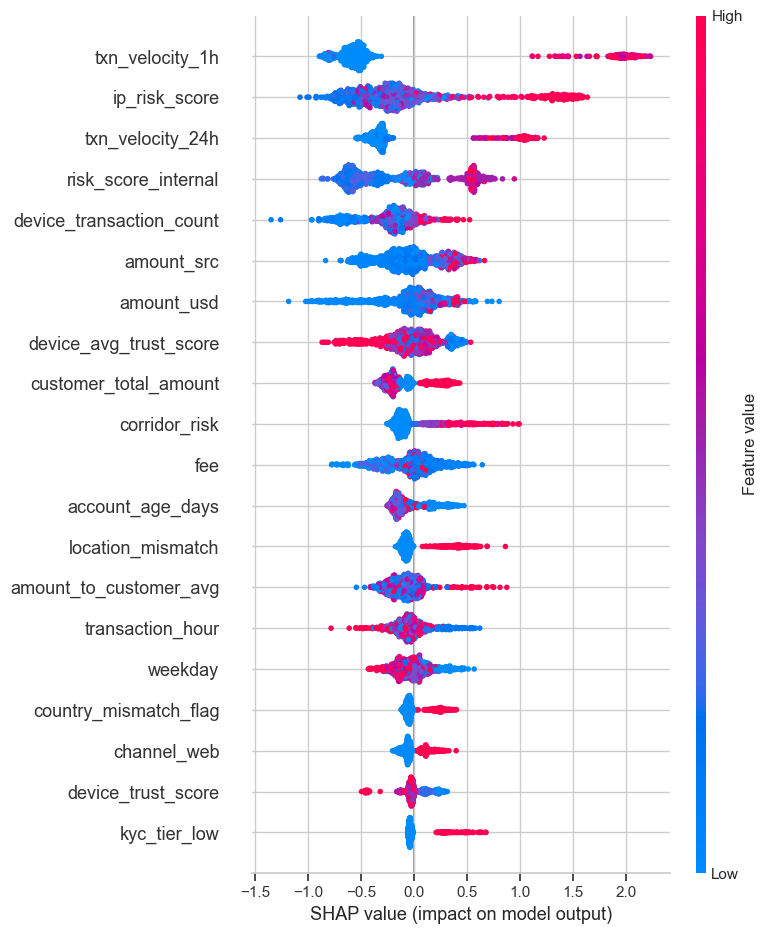

In [10]:
if shap_ready:
    plt.figure()
    shap.summary_plot(
        shap_values_sample_df.values,
        shap_sample,
        feature_names=shap_sample.columns,
        show=False,
        max_display=20,
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "global_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    if hasattr(final_estimator, "feature_importances_"):
        fallback_importance_df = pd.DataFrame(
            {
                "feature": X_test_transformed_df.columns,
                "importance": final_estimator.feature_importances_,
            }
        ).sort_values("importance", ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=fallback_importance_df, x="importance", y="feature", ax=ax)
        ax.set_title("Fallback Global Feature Importance")
        ax.set_xlabel("Importance")
        ax.set_ylabel("")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "global_shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print("No SHAP values or feature importances are available for this model.")

## 10. Reason Code Mapping

The mapping below turns model features into plain-English reason codes suitable for fraud analysts and stakeholder review.

In [19]:
REASON_CODE_MAP = {
    "txn_velocity_24h": "High transaction activity in the last 24 hours increased fraud risk.",
    "txn_velocity_1h": "Short-term transaction burst increased fraud risk.",
    "ip_risk_score": "The transaction originated from a high-risk IP environment.",
    "device_trust_score": "Low device trust increased fraud risk.",
    "device_avg_trust_score": "Historical device trust pattern influenced the fraud risk score.",
    "amount_to_customer_avg": "The transaction amount was unusual compared with the customer's normal behaviour.",
    "customer_amount_std": "Customer transaction amounts show high variability.",
    "account_age_days": "Account age influenced the model's risk judgement.",
    "location_mismatch": "The IP country differed from the customer's registered country.",
    "country_mismatch_flag": "A country mismatch contributed to the risk score.",
    "chargeback_history_count": "Previous chargeback activity increased risk.",
    "risk_score_internal": "Internal risk score contributed to the prediction.",
    "corridor_risk": "The transfer corridor risk contributed to the prediction.",
}


def make_reason_code(feature_name, shap_value):
    base_feature = str(feature_name).split("_")[-1] if str(feature_name).startswith("onehot_") else str(feature_name)
    for key, message in REASON_CODE_MAP.items():
        if key in str(feature_name):
            if shap_value >= 0:
                return message
            return f"{message} This feature reduced the predicted fraud risk."
    if shap_value >= 0:
        return f"{feature_name} increased the predicted fraud risk."
    return f"{feature_name} reduced the predicted fraud risk."

## 11. Local Transaction Explanation Function

The function below returns a transaction-level explanation with top positive and negative contributors, fraud probability, confidence score, and reason codes.

In [12]:
def feature_importance_fallback_values():
    if hasattr(final_estimator, "feature_importances_"):
        return pd.Series(final_estimator.feature_importances_, index=X_test_transformed_df.columns)
    return pd.Series(np.zeros(X_test_transformed_df.shape[1]), index=X_test_transformed_df.columns)


def explain_transaction(row_index, top_n=5):
    if row_index not in prediction_review_df.index:
        raise KeyError(f"row_index {row_index} is not in the test-set index.")

    review_row = prediction_review_df.loc[row_index]

    if shap_ready:
        contributions = shap_values_df.loc[row_index].sort_values(ascending=False)
    else:
        signed_direction = 1 if review_row["predicted_label"] == 1 else -1
        contributions = (feature_importance_fallback_values() * signed_direction).sort_values(ascending=False)

    top_positive = contributions[contributions > 0].head(top_n)
    top_negative = contributions[contributions < 0].sort_values().head(top_n)

    rows = []
    rank = 1
    for direction, series in [("Increased fraud risk", top_positive), ("Reduced fraud risk", top_negative)]:
        for feature, value in series.items():
            rows.append(
                {
                    "transaction_id": review_row["transaction_id"],
                    "actual_label": int(review_row["actual_label"]),
                    "predicted_label": int(review_row["predicted_label"]),
                    "fraud_probability": float(review_row["fraud_probability"]),
                    "confidence_score": float(review_row["confidence_score"]),
                    "rank": rank,
                    "feature": feature,
                    "contribution_value": float(value),
                    "contribution_direction": direction,
                    "reason_code": make_reason_code(feature, value),
                }
            )
            rank += 1

    return pd.DataFrame(rows)

## 12. Explain Example Transactions

The notebook saves local explanations for one true positive, one false positive, one false negative if available, and one true negative.

In [14]:
outcome_to_filename = {
    "True Positive": "true_positive_explanation.csv",
    "False Positive": "false_positive_explanation.csv",
    "False Negative": "false_negative_explanation.csv",
    "True Negative": "true_negative_explanation.csv",
}

explanation_examples = {}
for outcome, filename in outcome_to_filename.items():
    matching = prediction_review_df[prediction_review_df["review_outcome"] == outcome]
    if matching.empty:
        print(f"No {outcome.lower()} examples available in the test set.")
        continue
    row_index = matching.sort_values("confidence_score", ascending=False).index[0]
    explanation = explain_transaction(row_index, top_n=5)
    explanation.to_csv(ARTIFACTS_DIR / filename, index=False)
    explanation_examples[outcome] = explanation
    print(f"Saved {outcome} explanation to {filename}")
    display(explanation)

Saved True Positive explanation to true_positive_explanation.csv


,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,rank,feature,contribution_value,contribution_direction,reason_code
0,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,1,txn_velocity_1h,1.869013,Increased fraud risk,Short-term transaction burst increased fraud r...
1,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,2,ip_risk_score,1.277206,Increased fraud risk,The transaction originated from a high-risk IP...
2,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,3,txn_velocity_24h,0.963847,Increased fraud risk,High transaction activity in the last 24 hours...
3,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,4,risk_score_internal,0.562777,Increased fraud risk,Internal risk score contributed to the predict...
4,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,5,amount_src,0.536035,Increased fraud risk,amount_src increased the predicted fraud risk.
5,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,6,device_transaction_count,-0.121563,Reduced fraud risk,device_transaction_count reduced the predicted...
6,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,7,customer_total_amount,-0.067320,Reduced fraud risk,customer_total_amount reduced the predicted fr...
7,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,8,ip_country_US,-0.008439,Reduced fraud risk,ip_country_US reduced the predicted fraud risk.
8,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,9,customer_transaction_count,-0.008173,Reduced fraud risk,customer_transaction_count reduced the predict...
9,2c33b6ab-c4a2-4f9b-97ec-a543ae3d7d0b,1,1,0.999874,0.999874,10,dest_currency_CNY,-0.006982,Reduced fraud risk,dest_currency_CNY reduced the predicted fraud ...


Saved False Positive explanation to false_positive_explanation.csv


,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,rank,feature,contribution_value,contribution_direction,reason_code
0,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,1,risk_score_internal,0.765653,Increased fraud risk,Internal risk score contributed to the predict...
1,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,2,corridor_risk,0.619789,Increased fraud risk,The transfer corridor risk contributed to the ...
2,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,3,transaction_hour,0.576334,Increased fraud risk,transaction_hour increased the predicted fraud...
3,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,4,account_age_days,0.429312,Increased fraud risk,Account age influenced the model's risk judgem...
4,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,5,customer_total_amount,0.393126,Increased fraud risk,customer_total_amount increased the predicted ...
5,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,6,txn_velocity_1h,-0.363879,Reduced fraud risk,Short-term transaction burst increased fraud r...
6,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,7,ip_risk_score,-0.290620,Reduced fraud risk,The transaction originated from a high-risk IP...
7,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,8,txn_velocity_24h,-0.227519,Reduced fraud risk,High transaction activity in the last 24 hours...
8,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,9,channel_web,-0.158462,Reduced fraud risk,channel_web reduced the predicted fraud risk.
9,1740be09-eea5-474a-8a0c-de167ea6ff31,0,1,0.941241,0.941241,10,channel_mobile,-0.076542,Reduced fraud risk,channel_mobile reduced the predicted fraud risk.


Saved False Negative explanation to false_negative_explanation.csv


,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,rank,feature,contribution_value,contribution_direction,reason_code
0,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,1,channel_mobile,0.082384,Increased fraud risk,channel_mobile increased the predicted fraud r...
1,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,2,channel_web,0.073790,Increased fraud risk,channel_web increased the predicted fraud risk.
2,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,3,fee,0.043641,Increased fraud risk,fee increased the predicted fraud risk.
3,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,4,dest_currency_CAD,0.019015,Increased fraud risk,dest_currency_CAD increased the predicted frau...
4,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,5,device_trust_band_Medium,0.018382,Increased fraud risk,device_trust_band_Medium increased the predict...
5,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,6,txn_velocity_1h,-0.667798,Reduced fraud risk,Short-term transaction burst increased fraud r...
6,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,7,risk_score_internal,-0.541270,Reduced fraud risk,Internal risk score contributed to the predict...
7,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,8,txn_velocity_24h,-0.337011,Reduced fraud risk,High transaction activity in the last 24 hours...
8,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,9,device_avg_trust_score,-0.329842,Reduced fraud risk,Historical device trust pattern influenced the...
9,816877db-1422-433c-b77f-dc33ec5b4dc4,1,0,0.013889,0.986111,10,customer_total_amount,-0.328729,Reduced fraud risk,customer_total_amount reduced the predicted fr...


Saved True Negative explanation to true_negative_explanation.csv


,transaction_id,actual_label,predicted_label,fraud_probability,confidence_score,rank,feature,contribution_value,contribution_direction,reason_code
0,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,1,kyc_tier_standard,0.038604,Increased fraud risk,kyc_tier_standard increased the predicted frau...
1,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,2,dest_currency_CAD,0.011974,Increased fraud risk,dest_currency_CAD increased the predicted frau...
2,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,3,corridor_UK_to_CNY,0.004544,Increased fraud risk,corridor_UK_to_CNY increased the predicted fra...
3,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,4,corridor_US_to_USD,0.004452,Increased fraud risk,corridor_US_to_USD increased the predicted fra...
4,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,5,device_trust_band_Medium,0.004098,Increased fraud risk,device_trust_band_Medium increased the predict...
5,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,6,amount_usd,-0.676774,Reduced fraud risk,amount_usd reduced the predicted fraud risk.
6,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,7,risk_score_internal,-0.620178,Reduced fraud risk,Internal risk score contributed to the predict...
7,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,8,fee,-0.577419,Reduced fraud risk,fee reduced the predicted fraud risk.
8,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,9,ip_risk_score,-0.569699,Reduced fraud risk,The transaction originated from a high-risk IP...
9,e7d6685b-c212-425f-8d8f-d790592de70b,0,0,0.001807,0.998193,10,txn_velocity_1h,-0.531781,Reduced fraud risk,Short-term transaction burst increased fraud r...


## 13. False Positive Analysis

False positives often occur when legitimate customer behaviour resembles known fraud patterns: high transaction velocity, unusual amount, new device use, high IP risk, or location mismatch.

,feature,average_positive_shap
0,risk_score_internal,0.413969
1,corridor_risk,0.227744
2,customer_total_amount,0.216075
3,account_age_days,0.190826
4,amount_src,0.175001
5,amount_usd,0.174024
6,txn_velocity_1h,0.145697
7,fee,0.120935
8,location_mismatch,0.117344
9,device_avg_trust_score,0.117105


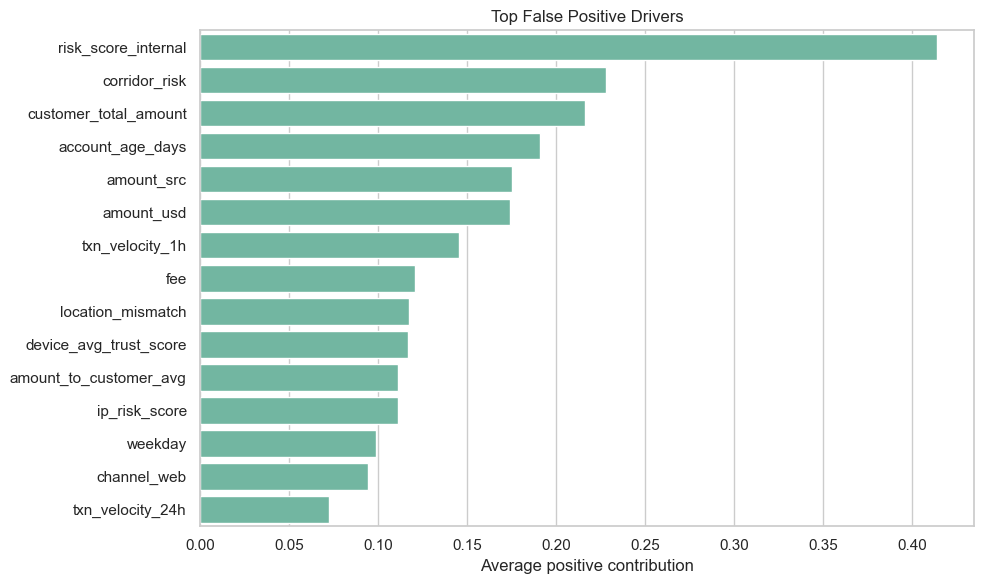

In [15]:
if shap_ready and not false_positives_df.empty:
    fp_shap = shap_values_df.loc[false_positives_df.index]
    top_fp_features = (
        fp_shap.clip(lower=0)
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .rename_axis("feature")
        .reset_index(name="average_positive_shap")
    )
elif not false_positives_df.empty:
    top_fp_features = (
        feature_importance_fallback_values()
        .sort_values(ascending=False)
        .head(15)
        .rename_axis("feature")
        .reset_index(name="average_positive_shap")
    )
else:
    top_fp_features = pd.DataFrame(columns=["feature", "average_positive_shap"])

top_fp_features.to_csv(ARTIFACTS_DIR / "false_positive_driver_features.csv", index=False)
display(top_fp_features)

if not top_fp_features.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=top_fp_features, x="average_positive_shap", y="feature", ax=ax)
    ax.set_title("Top False Positive Drivers")
    ax.set_xlabel("Average positive contribution")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "false_positive_drivers.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No false positives were available for driver analysis.")

## 14. Stakeholder Review Template

The template below gives analysts a consistent format for explaining model alerts, documenting reason codes, and recording the review decision.

In [17]:
stakeholder_template = '# NovaPay Fraud Alert Review Template\n\n## Transaction Summary\n- Transaction ID:\n- Review Date:\n- Analyst:\n- Model Version:\n- Prediction:\n- Fraud Probability:\n- Confidence Score:\n- Actual Outcome if known:\n\n## Reason Codes\n| Rank | Reason Code | Feature | Contribution Direction | Analyst Interpretation |\n|------|-------------|---------|------------------------|------------------------|\n| 1 |  |  |  |  |\n| 2 |  |  |  |  |\n| 3 |  |  |  |  |\n\n## Customer and Transaction Context\n- Amount:\n- Channel:\n- Home Country:\n- IP Country:\n- KYC Tier:\n- Device Trust:\n- Transaction Velocity 1h:\n- Transaction Velocity 24h:\n- Chargeback History:\n\n## Analyst Decision\n- [ ] Approve transaction\n- [ ] Manual review\n- [ ] Temporarily hold\n- [ ] Escalate to fraud investigation\n\n## Analyst Notes\nFree-text notes.\n\n## Recommended Follow-up\n- [ ] Contact customer\n- [ ] Verify device\n- [ ] Request additional KYC\n- [ ] Monitor account\n- [ ] Close alert as false positive\n'
example_false_positive_template = "# NovaPay Fraud Alert Review Template\n\n## Transaction Summary\n- Transaction ID: FP_EXAMPLE_FROM_DAY7\n- Review Date: 2026-07-03\n- Analyst: Fraud Operations Analyst\n- Model Version: Day 6 best advanced model\n- Prediction: Fraud alert\n- Fraud Probability: Populate from `false_positive_explanation.csv`\n- Confidence Score: Populate from `false_positive_explanation.csv`\n- Actual Outcome if known: Legitimate transaction, false positive\n\n## Reason Codes\n| Rank | Reason Code | Feature | Contribution Direction | Analyst Interpretation |\n|------|-------------|---------|------------------------|------------------------|\n| 1 | High transaction activity in the last 24 hours increased fraud risk. | txn_velocity_24h | Increased fraud risk | Customer activity resembled known rapid-transfer fraud behaviour. |\n| 2 | The transaction amount was unusual compared with the customer's normal behaviour. | amount_to_customer_avg | Increased fraud risk | Amount pattern looked unusual but may reflect a genuine urgent payment. |\n| 3 | Low device trust increased fraud risk. | device_trust_score | Increased fraud risk | Customer may have recently changed phone or browser. |\n\n## Customer and Transaction Context\n- Amount: Populate from transaction row\n- Channel: Populate from transaction row\n- Home Country: Populate from transaction row\n- IP Country: Populate from transaction row\n- KYC Tier: Populate from transaction row\n- Device Trust: Populate from transaction row\n- Transaction Velocity 1h: Populate from transaction row\n- Transaction Velocity 24h: Populate from transaction row\n- Chargeback History: Populate from transaction row\n\n## Analyst Decision\n- [ ] Approve transaction\n- [x] Manual review\n- [ ] Temporarily hold\n- [ ] Escalate to fraud investigation\n\n## Analyst Notes\nThis alert should be reviewed as a likely false positive if customer identity, device ownership, and payment intent are confirmed. The reason codes are meaningful risk signals, but they can also occur during legitimate travel, device replacement, urgent family transfers, or repeated payments.\n\n## Recommended Follow-up\n- [x] Contact customer\n- [x] Verify device\n- [ ] Request additional KYC\n- [x] Monitor account\n- [ ] Close alert as false positive\n"

template_path = TEMPLATE_DIR / "stakeholder_review_template.md"
example_template_path = TEMPLATE_DIR / "example_false_positive_review.md"

template_path.write_text(stakeholder_template, encoding="utf-8")
example_template_path.write_text(example_false_positive_template, encoding="utf-8")

print("Template saved to:", template_path)
print("Example template saved to:", example_template_path)

Template saved to: C:\Users\sadeq\reports\templates\day7\stakeholder_review_template.md
Example template saved to: C:\Users\sadeq\reports\templates\day7\example_false_positive_review.md


## 15. Reflection

**Which features most often lead to false positives and why?**

False positives are most likely driven by features that are strong fraud indicators but can also occur in legitimate behaviour. These include high transaction velocity, unusual transaction amount compared with customer history, high IP risk score, country mismatch, new or low-trust devices, and recent account activity.

These signals may resemble fraud but can also happen for genuine customers, such as travellers, migrant workers, customers using VPNs, customers replacing phones, or customers sending urgent repeated payments. That is why the model explanation should be paired with analyst context rather than treated as an automatic final judgement.

These findings demonstrate that many false positives arise because genuine customer behaviour occasionally resembles historical fraud patterns. Explainability techniques such as SHAP help analysts distinguish genuine risk indicators from legitimate but unusual customer activity, improving trust in the model.

## 16. Assessment Response

**Explain to a stakeholder why a legitimate transaction was mistakenly flagged and how you would adjust the model.**

A legitimate transaction may be flagged because it shared characteristics with known fraud cases. For example, the customer may have made several transfers in a short time, used a new device, had a high IP risk score, or sent an amount that differed from their usual pattern. The model interpreted these signals as suspicious based on historical fraud patterns. However, because the transaction was later confirmed as legitimate, this is a false positive.

To reduce similar false positives, I would review the decision threshold, recalibrate the model, investigate whether certain features are over-weighted, add more customer history features, and monitor false positive patterns over time. I would also use analyst feedback to retrain the model so it learns the difference between genuine unusual behaviour and actual fraud.

## 17. Final Outputs Checklist

- [x] `07_explainability.ipynb` completed
- [x] SHAP global explanation generated
- [x] Local transaction explanations generated
- [x] False positive analysis completed
- [x] Stakeholder review template created
- [x] Example filled template created
- [x] Reflection completed
- [x] Assessment response completed

## 18. Save Final Summary

The summary JSON records the model used, test-set size, false positive and false negative counts, top false-positive drivers, and template paths.

In [18]:
summary = {
    "model_used": model_used,
    "number_of_test_transactions": int(len(prediction_review_df)),
    "number_of_false_positives": int((prediction_review_df["review_outcome"] == "False Positive").sum()),
    "number_of_false_negatives": int((prediction_review_df["review_outcome"] == "False Negative").sum()),
    "top_false_positive_features": top_fp_features["feature"].head(10).tolist() if not top_fp_features.empty else [],
    "template_path": str(TEMPLATE_DIR / "stakeholder_review_template.md"),
    "example_template_path": str(TEMPLATE_DIR / "example_false_positive_review.md"),
}

with open(ARTIFACTS_DIR / "day7_explainability_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "model_used": "Day 6 saved advanced model",
  "number_of_test_transactions": 2188,
  "number_of_false_positives": 102,
  "number_of_false_negatives": 20,
  "top_false_positive_features": [
    "risk_score_internal",
    "corridor_risk",
    "customer_total_amount",
    "account_age_days",
    "amount_src",
    "amount_usd",
    "txn_velocity_1h",
    "fee",
    "location_mismatch",
    "device_avg_trust_score"
  ],
  "template_path": "C:\\Users\\sadeq\\reports\\templates\\day7\\stakeholder_review_template.md",
  "example_template_path": "C:\\Users\\sadeq\\reports\\templates\\day7\\example_false_positive_review.md"
}
